In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.cm import get_cmap

# Load the texture coefficients from the CSV file
csv_file = "texture_coefficients.csv"
data = pd.read_csv(csv_file)

# Select only the last 4 rows of the file
data = data.tail(4)  # Keeps the last 4 rows

# Specify the peaks to plot
peaks_to_plot = ["120", "221"]



# Extract the data for the specified peaks

# Add brackets around the hkl numbers
x_labels = [f"({hkl})" for hkl in peaks_to_plot]

# Remove the .xy extension from the sample names
samples = data["File"].str.replace(".xy", "", regex=False)

tc_values = data[peaks_to_plot]  # TC values for the specified peaks

print(data)


                             File       020       120       220       211  \
3  10_25_07_0mM_baseline_Sb2S3.xy  1.065635  1.310372  1.360332  0.556328   
4                  7_14_07_4mM.xy  0.975191  1.272337  1.456767  0.536622   
5                  8_14_07_8mM.xy  0.960496  1.196040  1.396093  0.686192   
6                9_14_07_12_mM.xy  1.186546  1.312829  1.257167  0.485761   

        221       240  
3  0.764915  0.942418  
4  0.761245  0.997837  
5  0.857355  0.903825  
6  0.719877  1.037820  


C:\Users\Fardin\AppData\Local\Temp\ipykernel_25604\2779554055.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  viridis = get_cmap("viridis", 4)


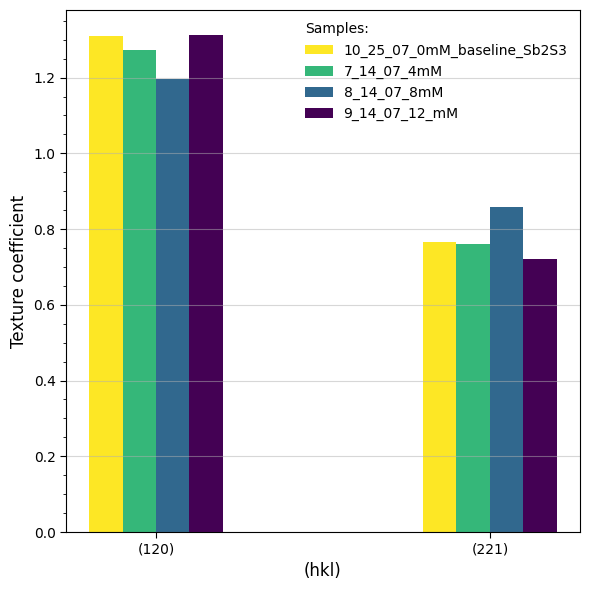

In [24]:

# Create the bar plot
x = np.arange(len(x_labels))  # X positions for the peaks
bar_width = 0.1  # Thinner bars for a cleaner look

fig, ax = plt.subplots(figsize=(6, 6))  # Adjust figure size for better proportions

# Define a muted color palette
#colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b"]
#colors = [ "#d62728","#1f77b4"]  # Blue for lower temp, red for higher temp
#colors = ["#2ca02c"]  

# Use the Viridis colormap to generate 4 evenly spaced colors, reversed
viridis = get_cmap("viridis", 4)
colors = [viridis(i) for i in reversed(range(4))]  # Reverse the order of colors

'''colors = [
        "#909090",  # light grey
        "#607090",  # greyish blue
        "#4060B0",  # medium blue
        "#2040D0",  # strong blue
        "#0033CC"   # deep blue
    ]'''

# Plot bars for each sample
for i, sample in enumerate(samples):
    ax.bar(x + i * bar_width, tc_values.iloc[i], bar_width, label=sample, color=colors[i % len(colors)])

# Customize the plot
ax.set_xlabel("(hkl)", fontsize=12, fontname="DejaVu Sans")
ax.set_ylabel("Texture coefficient", fontsize=12, fontname="DejaVu Sans")
#ax.set_title("Texture Coefficients for Selected Peaks", fontsize=14, fontname="DejaVu Sans", pad=15)
ax.set_xticks(x + bar_width * (len(samples) - 1) / 2)
ax.set_xticklabels(x_labels, fontsize=10, fontname="DejaVu Sans")
#ax.set_yticks(np.arange(0, 1.2, 0.1))
ax.legend(title="Samples:", alignment="left", fontsize=10, title_fontsize=10, loc="upper right", frameon=False)
ax.grid(axis="y", linestyle="-", alpha=0.5)

plt.gca().tick_params(axis='x', which='minor', bottom=False)
plt.minorticks_on()

# Adjust axis line width and ticks
ax.tick_params(axis="both", which="major", labelsize=10, width=0.8, length=4)

# Show the plot

plt.tight_layout()
plt.savefig(r"G:\My Drive\PhD\Research\Sb2S3 paper\Texture coefficient figures\TC samples 7-10.png", dpi=600) # Uncomment to save
plt.show()